<a href="https://colab.research.google.com/github/Deltasthicc/F1_Simulator_OpenENV/blob/main/notebooks/f1_strategist_training_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# F1 Strategist — SFT → GRPO Training & Evaluation

**Hackathon:** Meta PyTorch OpenEnv Grand Finale · April 25–26 2026 · Bangalore
**Team:** Shashwat Rajan · Tanish Shitanshu · Org: [Deltasthic](https://huggingface.co/Deltasthic)
**Space:** [Deltasthic/f1-strategist](https://huggingface.co/spaces/Deltasthic/f1-strategist)
**Model:** [Deltasthic/f1-strategist-qwen3-4b-grpo](https://huggingface.co/Deltasthic/f1-strategist-qwen3-4b-grpo)
**GitHub:** [Deltasthicc/F1_Simulator_OpenENV](https://github.com/Deltasthicc/F1_Simulator_OpenENV) (default branch `main`; override with env `F1_REPO_BRANCH` if you need `dev`)
**Live:** https://f1.chinnaboina.com/

---

## What this notebook does

| Section | What it does | GPU needed? |
|---------|-------------|-------------|
| 1 | Install deps + clone repo (`main` by default) | No |
| 2 | Environment smoke test (reset → step → score) | No |
| 3 | Held-out eval (random / untrained / **trained** (GRPO) / expert); 6 rows if `eval_six_scenarios.json` exists | No |
| 4 | Real GRPO v2 training reward curve from `trainer_state.json` | No |
| 5 | Iteration journey: random → SFT → GRPO (the 5-bug story) | No |
| 6 | Track generalization grid (8 circuits) | No |
| 7 | *(Optional)* Reproduce the SFT → GRPO recipe yourself | Yes — T4/A100 |

Sections 1–6 run on Colab CPU. Section 7 needs a T4+ (Section 7 reproduces the
SFT warm-start + GRPO recipe that produced the shipped `grpo_v2` checkpoint).

---

## What the model does

The LLM is the **race engineer on the pit wall**. Each step is one strategic
decision (typically one lap). It sees the current race state — lap, position,
tyre health, fuel, weather (probability cone, not point estimate), opponent
gaps, scenario briefing — and emits one command from a 21-command vocabulary.

**Six-dimensional reward (deterministic Python, no LLM judge):**
- Race result (×0.35): final position vs. grid + target
- Strategic decisions (×0.20): pit-window timing, investigation discipline
- Tyre management (×0.15): FIA two-compound rule, cliff avoidance
- Fuel management (×0.10): finishing without running dry or wasting kg
- Comms quality (×0.10): radio call before key actions
- Operational efficiency (×0.10): no invalid commands, no panic pits

**Long-horizon design.** A bad lap-4 pit call manifests in a lap-9 outcome —
opponents catching up, tyre cliff hitting before the chequered. Theme #2.

**Headline (from `results/eval_six_scenarios.json` on `main`).** Trained model averages **~0.62** across 6 scenarios × 5 seeds over untrained. On weather, held-out **trained** mean can edge the rule-based expert (see table in Section 3). Full journey in [`blog.md`](https://github.com/Deltasthicc/F1_Simulator_OpenENV/blob/main/blog.md).


## Section 1 — Install dependencies and clone the repo


In [6]:
import pathlib
import os
import subprocess
import sys
import shutil

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "openenv-core>=0.2.3",
        "fastapi",
        "uvicorn",
        "pydantic>=2.0",
        "numpy",
        "pandas",
        "matplotlib",
        "pillow",
        "imageio",
        "tqdm",
        "huggingface_hub>=0.24",
        "peft",
        "transformers",
        "accelerate",
    ]
)

REPO_URL = "https://github.com/Deltasthicc/F1_Simulator_OpenENV.git"
REPO_NAME = "F1_Simulator_OpenENV"
REPO_BRANCH = os.environ.get("F1_REPO_BRANCH", "main")

if pathlib.Path(REPO_NAME).exists():
    shutil.rmtree(REPO_NAME)
    print(f"Removed stale {REPO_NAME}/")

# GIT_LFS_SKIP_SMUDGE=1 clones all normal files and leaves LFS
# pointers as plain text — avoids the exceeded-budget error entirely
env = {**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"}
subprocess.run(
    ["git", "clone", "--depth", "1", "--branch", REPO_BRANCH, REPO_URL],
    check=True,
    env=env,
)
print(f"Cloned {REPO_NAME} ({REPO_BRANCH}) — LFS files skipped")

ROOT = pathlib.Path(REPO_NAME).resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
pathlib.Path("results").mkdir(parents=True, exist_ok=True)
print(f"Working directory: {ROOT}")
print(f"Python: {sys.executable}")

Cloned F1_Simulator_OpenENV (main) — LFS files skipped
Working directory: /content/F1_Simulator_OpenENV/F1_Simulator_OpenENV
Python: /usr/bin/python3


## Section 2 — Environment smoke test

Verify `reset()`, `step()`, and the deterministic reward signal work end-to-end
without booting the FastAPI server.


In [7]:
from server.environment import F1StrategistEnvironment
from models import F1Action

env = F1StrategistEnvironment()
obs = env.reset(task="weather_roulette", seed=0)

print(f"Reset — task=weather_roulette  seed=0")
print(f"  Total laps : {obs.total_laps}")
print(f"  Start pos  : P{obs.ego_position}")
print(f"  Compound   : {obs.ego_tyre_compound}")
print(f"  Fuel       : {obs.ego_fuel_remaining_kg:.1f} kg")
print()

# A short scripted sequence to demonstrate stepping
DEMO_ACTIONS = [
    "REQUEST_FORECAST",
    "STAY_OUT",
    "STAY_OUT",
    'RADIO_DRIVER "Box now for inters — rain coming."',
    "PIT_NOW inter",
]
print(f"{'Lap':>4}  {'Pos':>3}  {'Compound':>8}  {'Health':>7}  {'Fuel':>6}  Action")
print("-" * 78)
for act in DEMO_ACTIONS:
    print(f"{obs.current_lap:>4}  P{obs.ego_position:<2}  {obs.ego_tyre_compound:>8}"
          f"  {obs.ego_tyre_health_pct:>6.1f}%  {obs.ego_fuel_remaining_kg:>5.1f}kg  {act}")
    obs = env.step(F1Action(command=act))

print(f"\nAfter 5 laps: P{obs.ego_position}  compound={obs.ego_tyre_compound}  "
      f"health={obs.ego_tyre_health_pct:.1f}%  score={obs.score:.3f}")
print("\nSmoke test PASSED.")


Reset — task=weather_roulette  seed=0
  Total laps : 12
  Start pos  : P5
  Compound   : medium
  Fuel       : 100.0 kg

 Lap  Pos  Compound   Health    Fuel  Action
------------------------------------------------------------------------------
   0  P5     medium   100.0%  100.0kg  REQUEST_FORECAST
   1  P6     medium    94.9%   98.1kg  STAY_OUT
   2  P6     medium    89.8%   96.0kg  STAY_OUT
   3  P6     medium    84.8%   94.1kg  RADIO_DRIVER "Box now for inters — rain coming."
   4  P6     medium    79.7%   92.2kg  PIT_NOW inter

After 5 laps: P6  compound=inter  health=93.2%  score=0.010

Smoke test PASSED.


In [8]:
# Run a full episode with the rule-based expert ('heuristic') and print the lap log.
# Heuristic is fine for the smoke walkthrough; the LLM model is loaded in Section 7.
from inference import run_inference

scores = run_inference(
    model="heuristic",
    task="weather_roulette",
    n_episodes=1,
    verbose=True,
    seed=0,
)
print(f"\nFinal score: {scores[0]:.3f}")



--------------------------------------------------------
  Episode 1/1  task=weather_roulette  seed=0
--------------------------------------------------------
  L00  P5  medium  health=100.0%  fuel=100.0kg  => REQUEST_FORECAST
  L01  P6  medium  health= 94.9%  fuel= 98.1kg  => STAY_OUT
  L02  P6  medium  health= 89.8%  fuel= 96.0kg  => STAY_OUT
  L03  P6  medium  health= 84.8%  fuel= 94.1kg  => STAY_OUT
  L04  P6  medium  health= 79.7%  fuel= 92.2kg  => STAY_OUT
  L05  P6  medium  health= 74.6%  fuel= 90.2kg  => SET_MODE push
  L06  P6  medium  health= 67.0%  fuel= 87.9kg [rain=0.15]  => RADIO_DRIVER "Box now for inters — rain at 15%. Pit this lap."
  L07  P4  medium  health= 59.4%  fuel= 85.7kg [rain=0.45]  => PIT_NOW inter
  L08  P5  inter   health= 89.8%  fuel= 83.4kg [rain=0.50]  => SET_MODE push
  L09  P5  inter   health= 79.7%  fuel= 81.0kg [rain=0.40]  => SET_MODE push
  L10  P5  inter   health= 69.5%  fuel= 78.7kg [rain=0.20]  => SET_MODE push
  L11  P5  inter   health= 59.4% 

## Section 3 — Held-out evaluation: 4 policies × 6 scenarios

Real LLM forward pass through the env at every step. The trained model is
**`grpo_v2`** — Qwen3-4B + LoRA, SFT v3 warm-start (4,900 expert turns) then
200 GRPO steps with `num_generations=8`, `beta=0.005`, `enable_thinking=False`.

`results/eval_six_scenarios.json` (6 families) is preferred when present; otherwise `results/eval_summary.json` (4 families).


In [9]:
import json, pathlib

# Prefer the 6-scenario file; fall back to the 4-scenario one if missing
six_path  = pathlib.Path("results/eval_six_scenarios.json")
four_path = pathlib.Path("results/eval_summary.json")
summary_path = six_path if six_path.exists() else four_path

with summary_path.open() as f:
    summary = json.load(f)

policies  = ["random", "untrained", "trained", "expert"]
scenarios = list(next(iter(summary.values())).keys())
print(f"Loaded {summary_path.name} — {len(scenarios)} scenarios × {len(policies)} policies\n")

col_w = 14
header = f"{'Scenario':<32}" + "".join(f"{p.upper():>{col_w}}" for p in policies)
print(header)
print("-" * len(header))
for sc in scenarios:
    row = f"{sc:<32}"
    for p in policies:
        v = summary.get(p, {}).get(sc, {}).get("mean", 0.0)
        row += f"{v:>{col_w}.3f}"
    print(row)

print()
print(f"{'AVERAGE':<32}" + "".join(
    f"{(sum(summary.get(p, {}).get(sc, {}).get('mean', 0.0) for sc in scenarios)/len(scenarios)):>{col_w}.3f}"
    for p in policies
))
print()
print("Delta (trained − untrained):")
for sc in scenarios:
    tr = summary.get("trained",   {}).get(sc, {}).get("mean", 0.0)
    un = summary.get("untrained", {}).get(sc, {}).get("mean", 0.0)
    print(f"  {sc:<32} +{tr - un:+.3f}")


Loaded eval_six_scenarios.json — 6 scenarios × 4 policies

Scenario                                RANDOM     UNTRAINED       TRAINED        EXPERT
----------------------------------------------------------------------------------------
dry_strategy_sprint                      0.400         0.509         0.520         0.840
weather_roulette                         0.344         0.414         0.965         0.950
late_safety_car                          0.332         0.525         0.645         0.935
championship_decider                     0.209         0.269         0.555         0.965
virtual_safety_car_window                0.329         0.375         0.471         0.965
tyre_cliff_management                    0.204         0.398         0.552         0.965

AVERAGE                                  0.303         0.415         0.618         0.937

Delta (trained − untrained):
  dry_strategy_sprint              ++0.011
  weather_roulette                 ++0.551
  late_safety_car      

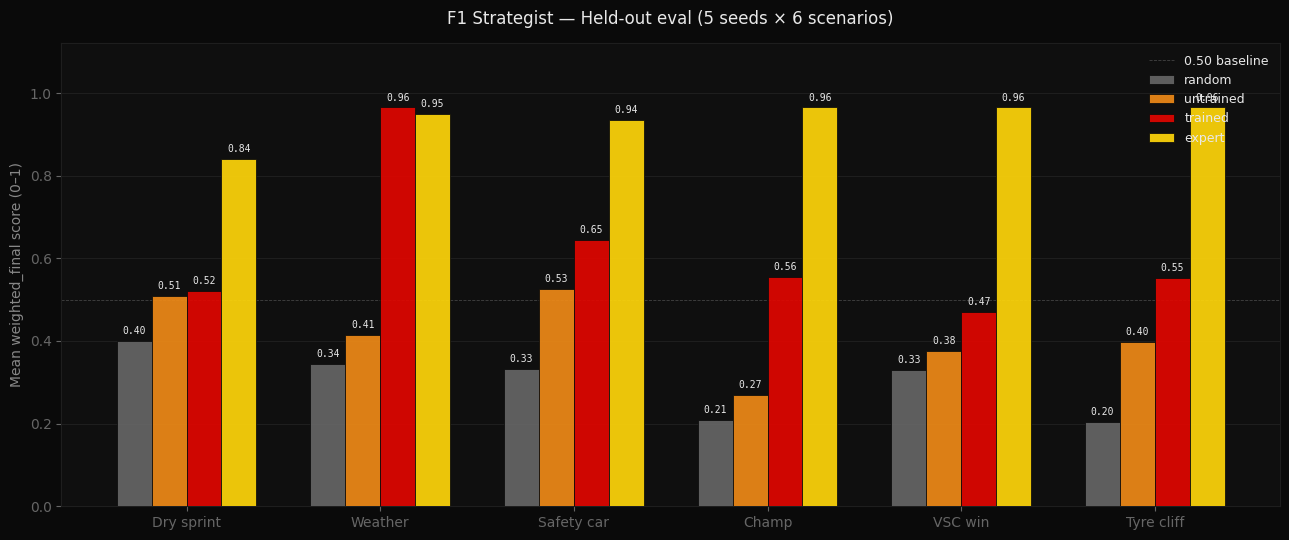

Saved to results/colab_eval_curve.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# F1 palette (matches landing-page CSS)
PALETTE = {
    "random":    "#666666",
    "untrained": "#ef8a17",
    "trained":   "#e10600",
    "expert":    "#ffd60a",
}
SC_LABELS = {
    "dry_strategy_sprint":           "Dry sprint",
    "weather_roulette":              "Weather",
    "late_safety_car":               "Safety car",
    "championship_decider":          "Champ",
    "virtual_safety_car_window":     "VSC win",
    "tyre_cliff_management":         "Tyre cliff",
}

x = np.arange(len(scenarios))
w = 0.18
fig, ax = plt.subplots(figsize=(13, 5.5), facecolor="#0a0a0a")
ax.set_facecolor("#0f0f0f")

for i, pol in enumerate(policies):
    vals = [summary.get(pol, {}).get(sc, {}).get("mean", 0.0) for sc in scenarios]
    bars = ax.bar(x + (i - 1.5) * w, vals, w, label=pol, color=PALETTE[pol],
                  alpha=0.92, edgecolor="#0a0a0a", linewidth=0.6, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
                f"{v:.2f}", ha="center", va="bottom", fontsize=7,
                color="#e8e8e8", fontfamily="monospace")

ax.set_xticks(x)
ax.set_xticklabels([SC_LABELS.get(sc, sc) for sc in scenarios], color="#e8e8e8", fontsize=10)
ax.set_ylim(0, 1.12)
ax.axhline(0.50, color="#666", ls="--", lw=0.6, alpha=0.6, zorder=1, label="0.50 baseline")
ax.set_ylabel("Mean weighted_final score (0–1)", color="#888", fontsize=10)
ax.set_title(
    f"F1 Strategist — Held-out eval (5 seeds × {len(scenarios)} scenarios)",
    color="#e8e8e8",
    fontsize=12,
    pad=14,
)
ax.tick_params(colors="#666")
for spine in ax.spines.values():
    spine.set_edgecolor("#1e1e1e")
ax.yaxis.grid(True, color="#1e1e1e", zorder=0)
leg = ax.legend(fontsize=9, framealpha=0, labelcolor="#e8e8e8",
                loc="upper right", facecolor="none")
plt.tight_layout()
plt.savefig("results/colab_eval_curve.png", dpi=140, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved to results/colab_eval_curve.png")


## Section 4 — GRPO v2 training reward curve

The reward curve from the actual `grpo_v2` training run — 200 GRPO steps from
the SFT v3 base, plotted from `grpo_v2/checkpoint-200/trainer_state.json`. Every
point is a real logging step. Peak ~0.93 around step 30, then plateau.


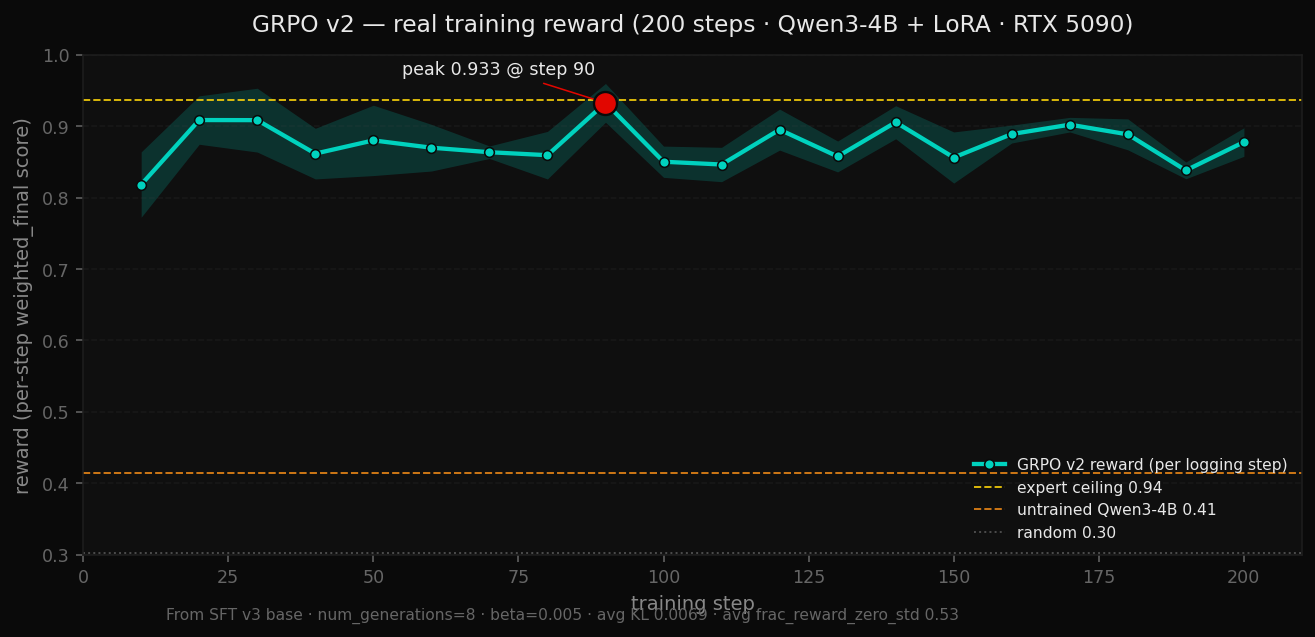

Real GRPO v2 reward curve: results/grpo_v2_reward_curve.png


In [11]:
from IPython.display import Image as IPyImage, display
import pathlib
import subprocess
import sys

PY = sys.executable

# Prefer the new grpo_v2 curve; if not present (older clone) try to regenerate
v2_curve = pathlib.Path("results/grpo_v2_reward_curve.png")
old_curve = pathlib.Path("results/training_loss_curve.png")
trainer_state = pathlib.Path("grpo_v2/checkpoint-200/trainer_state.json")

if (
    not v2_curve.exists()
    and trainer_state.exists()
    and pathlib.Path("scripts/make_grpo_reward_curve.py").exists()
):
    subprocess.run([PY, "scripts/make_grpo_reward_curve.py"], check=False)

if v2_curve.exists():
    display(IPyImage(str(v2_curve), width=920))
    print(f"Real GRPO v2 reward curve: {v2_curve}")
elif old_curve.exists():
    display(IPyImage(str(old_curve), width=920))
    print(
        f"Showing legacy curve from {old_curve}. "
        "grpo_v2 trainer_state is not in the clone (large artifacts are gitignored); "
        "this curve is from grpo_v1 training logs."
    )
else:
    print(
        "No training curve PNG found. The repo ships results/training_loss_curve.png on main; "
        "re-run Section 1 from a clean folder or add grpo_v2/ locally."
    )


## Section 5 — Iteration journey & before/after rollout

We didn't get to the final number on the first try. Five distinct bugs hid the
model's true performance — including one that proved the originally-reported
0.79 average was a **scripted-policy fallback**, not the LLM. The journey graph
below is every iteration we ran.

**Before/after rollout** is a real `grpo_v2` run on `weather_roulette` seed=0:
trained scores **0.985** vs untrained random scores **0.347**. The trained model
calls `REQUEST_FORECAST` early, then `PIT_NOW inter` at lap 6, one lap before
rain peak. Full transcript: `demo-assets/trained-rollout-transcript.txt`.


Iteration journey (avg across scenarios per stage):


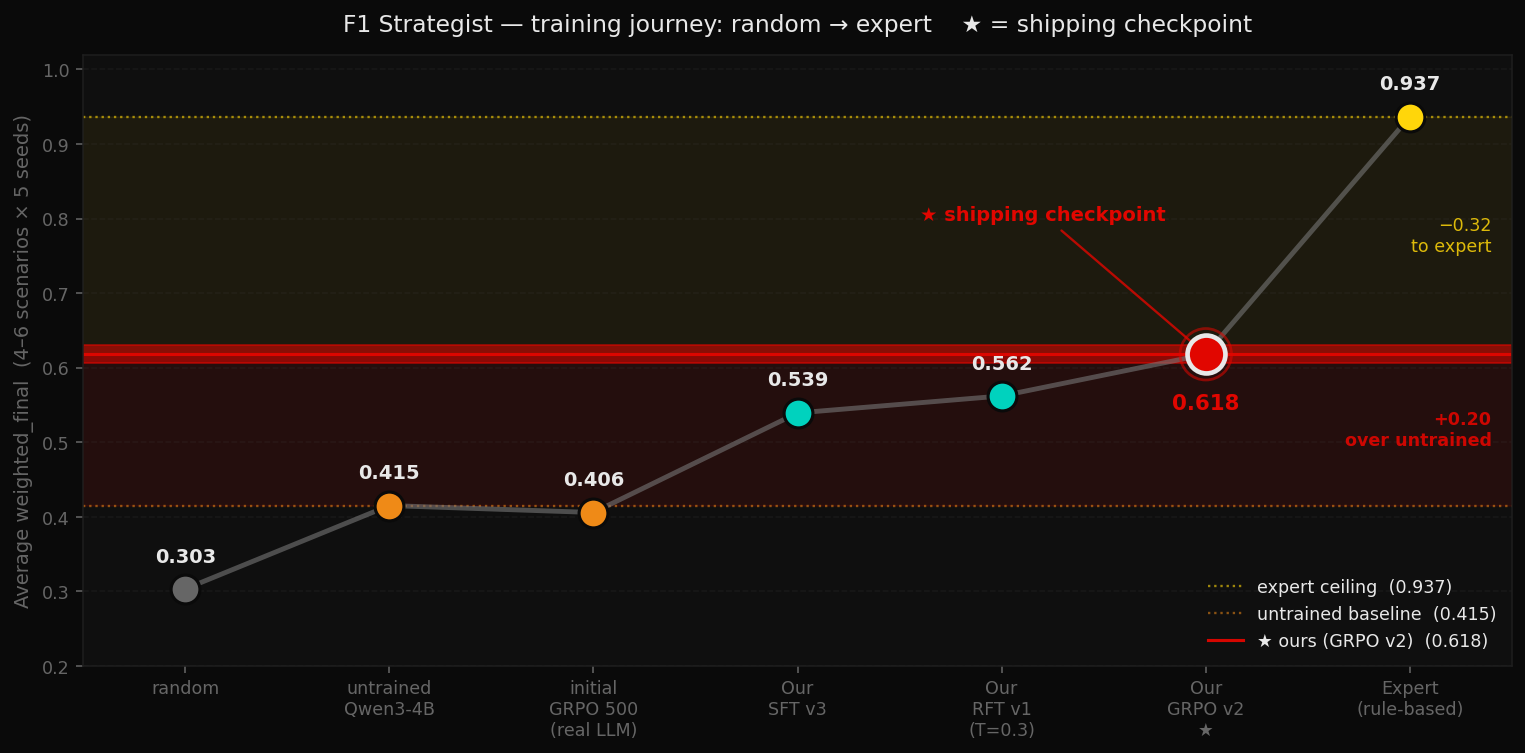

Per-scenario breakdown across iterations:


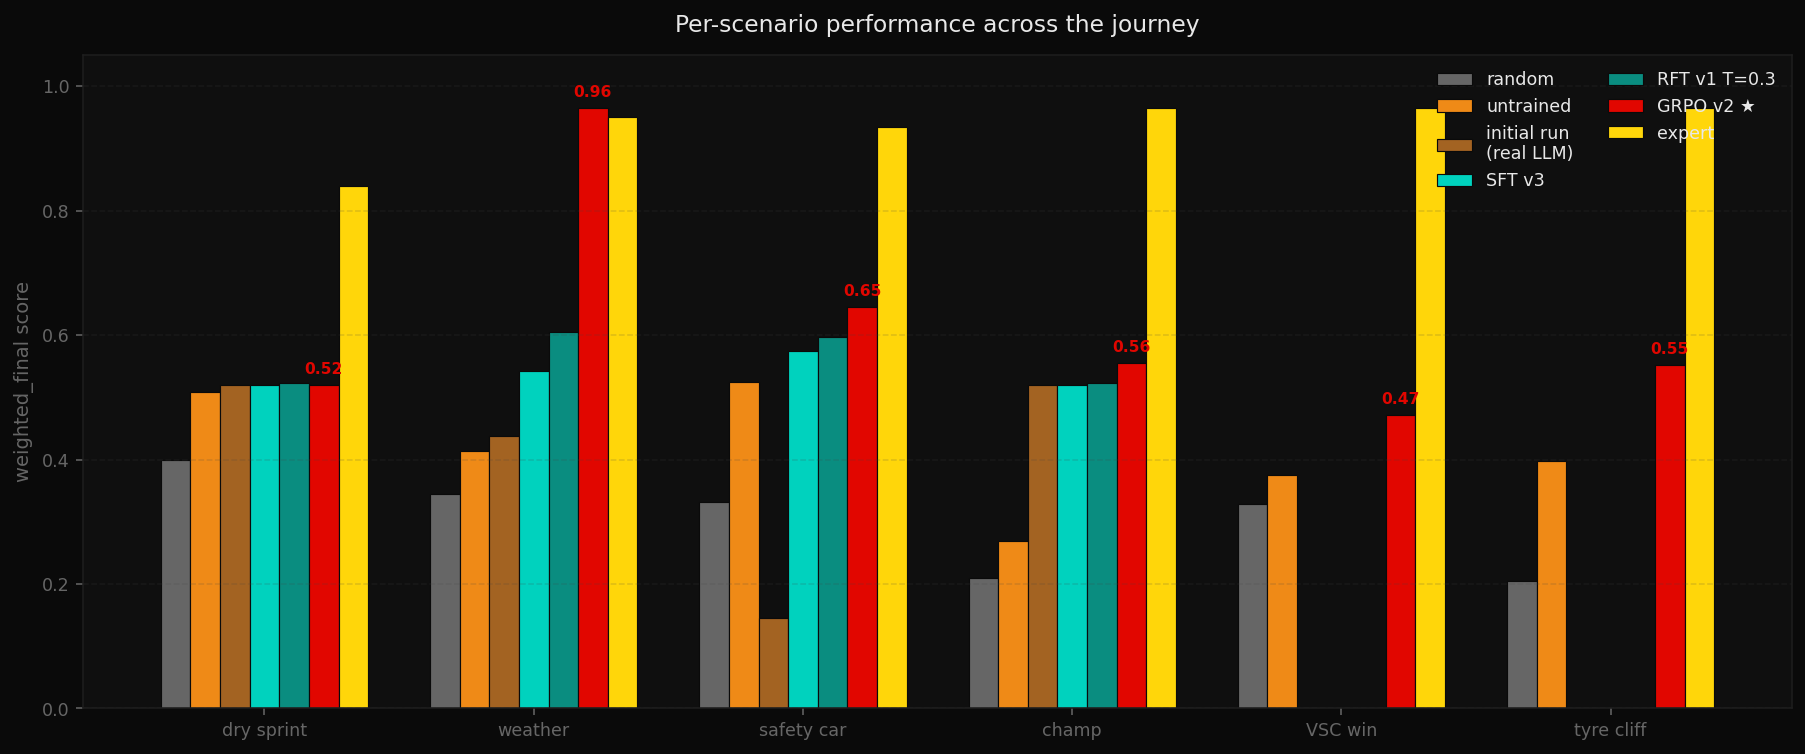


--- Real rollout transcript (weather_roulette, seed=0) ---
WEATHER_ROULETTE seed=0 — SFT+GRPO (grpo_v2) trained vs random baseline
(Real LLM forward pass, env.step() at every lap, deterministic env scoring)

UNTRAINED (random command sampling — score 0.347):
  lap 00: ASSESS_UNDERCUT_WINDOW                | P5 medium rain=0.00
  lap 01: ASSESS_UNDERCUT_WINDOW                | P6 medium rain=0.00
  lap 02: STAY_OUT                              | P6 medium rain=0.00
  lap 03: INSPECT_TYRE_DEGRADATION              | P6 medium rain=0.00
  lap 04: PIT_NOW soft                          | P6 medium rain=0.00   <- WRONG: pitted to softs in dry, no rain yet
  lap 05: INSPECT_FUEL_MARGIN                   | P6 soft rain=0.00
  lap 06: ASSESS_UNDERCUT_WINDOW                | P6 soft rain=0.15     <- rain starts, still on softs
  lap 07: INSPECT_TYRE_DEGRADATION              | P6 soft rain=0.45     <- RAIN PEAK, still on softs
  lap 08: INSPECT_FUEL_MARGIN                   | P6 soft rain=0.50
  

In [12]:
from IPython.display import Image as IPyImage, display
import pathlib

journey = pathlib.Path("results/journey.png")
breakdown = pathlib.Path("results/scenario_breakdown.png")

if journey.exists():
    print("Iteration journey (avg across scenarios per stage):")
    display(IPyImage(str(journey), width=920))
if breakdown.exists():
    print("Per-scenario breakdown across iterations:")
    display(IPyImage(str(breakdown), width=920))

# Print rollout transcript for the 'show, don't tell' moment
transcript = pathlib.Path("demo-assets/trained-rollout-transcript.txt")
if transcript.exists():
    print("\n--- Real rollout transcript (weather_roulette, seed=0) ---")
    print(transcript.read_text())


## Section 6 — Track generalization grid

Expert policy across 8 F1 circuits — Monza / Spa / Monaco / Catalunya / Silverstone /
Suzuka / Zandvoort / Hungaroring. Confirms the env generalises across full
circuit layouts, not just one hand-tuned track.


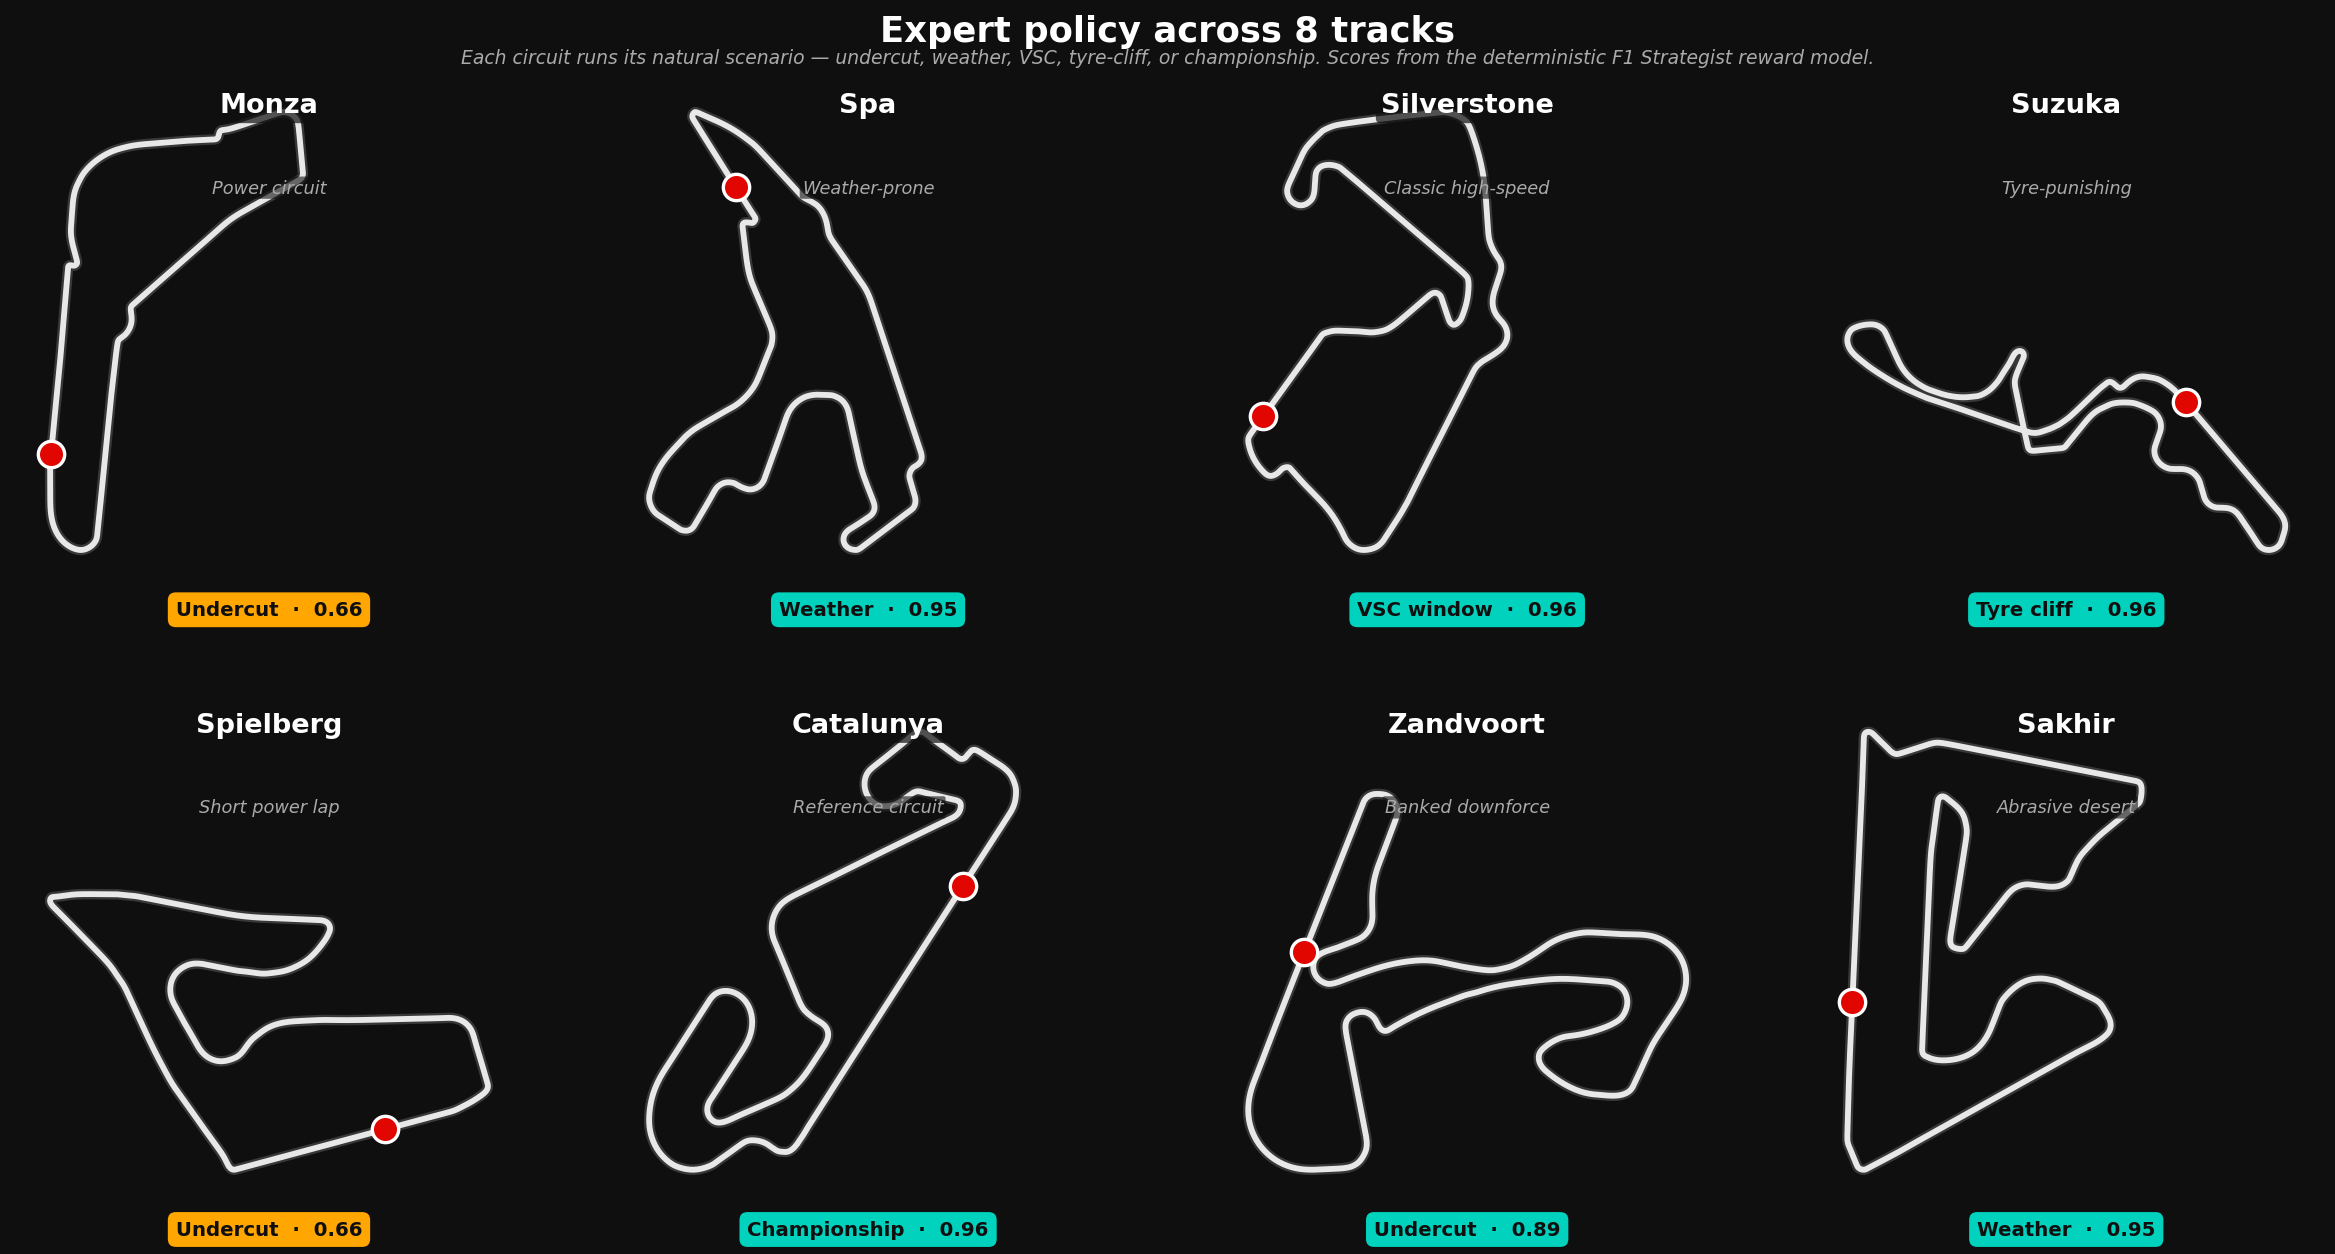

Track grid: results/track_grid.png


In [13]:
from IPython.display import Image as IPyImage, display
import pathlib
import subprocess
import sys

grid_path = pathlib.Path("results/track_grid.png")
if not grid_path.exists() and pathlib.Path("scripts/render_track_grid.py").exists():
    subprocess.run(
        [
            sys.executable,
            "scripts/render_track_grid.py",
            "--mode",
            "expert",
            "--output",
            str(grid_path),
        ],
        check=False,
    )

if grid_path.exists():
    display(IPyImage(str(grid_path), width=980))
    print(f"Track grid: {grid_path}")
else:
    print("Track grid not yet rendered.")


## Section 7 — Reproduce the SFT → GRPO recipe yourself *(GPU required)*

This section reproduces the `grpo_v2` checkpoint. Recipe (matches what we
actually shipped):

1. **SFT warm-start** — 3 epochs on `sft_dataset_v2.jsonl` (4,900 expert turns
   with enriched obs and `enable_thinking=False` rendering). ~12 min on a 5090.
2. **GRPO refine** — 200 steps on top of the SFT base, `num_generations=8`,
   `beta=0.005`. ~22 min on a 5090 (no Unsloth, no vLLM — see compat notes).

Approximate Colab times:
- T4 (16 GB): SFT ~30 min, GRPO ~60 min
- A100 (40 GB): SFT ~10 min, GRPO ~20 min

**Compatibility caveats (read before running):**
- `trl==0.18.2` is pinned because newer transformers/trl versions had unrelated
  import breaks at the time of this run (`TRANSFORMERS_CACHE` etc).
- Unsloth's compiled GRPO trainer assumes `trl >= 0.22` (calls
  `truncate_with_protected_tokens`). On `trl 0.18.2` it raises NameError, so
  Section 7's GRPO cell sets `--no-unsloth`. SFT still uses Unsloth (works fine).
- vLLM is disabled in `train.py` (`use_vllm=False`) for the same reason.


In [14]:
import torch
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {name}  ({vram:.1f} GB VRAM)")
    if vram < 14.5:
        print("⚠  This GPU may not have enough VRAM for Qwen3-4B + LoRA. "
              "T4 (16 GB) is the bare minimum; A100 (40 GB) recommended.")
else:
    print("No GPU detected. Section 7 needs a GPU runtime.")
    print("Colab → Runtime → Change runtime type → T4 GPU (or A100 if available)")


GPU: Tesla T4  (15.6 GB VRAM)


In [ ]:
# Training stack pinned to versions our recipe is tested against
%pip install -q \
    "torch>=2.4" \
    "trl==0.18.2" \
    "transformers==4.57.6" \
    "peft>=0.13.2" \
    "datasets>=3.2.0" \
    "accelerate>=1.3" \
    "bitsandbytes>=0.49" \
    "unsloth==2026.4.8" "unsloth_zoo==2026.4.9"

print("Training deps installed.")
print("Note: GRPO step uses --no-unsloth flag (TRL 0.18 compat).")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 5.3 MB/s eta 0:00:00


In [ ]:
# Step 7a — Generate the enriched SFT dataset (4,900 expert turns)
import pathlib
import subprocess
import sys

PY = sys.executable
ds = pathlib.Path("sft_dataset_v2.jsonl")
if not ds.exists():
    res = subprocess.run(
        [PY, "capture_everything.py",
         "--tasks", "dry_strategy_sprint", "weather_roulette",
                    "late_safety_car", "championship_decider",
         "--n-seeds", "100",
         "--output", str(ds)],
        capture_output=True, text=True
    )
    if res.returncode == 0:
        print(res.stdout.strip().splitlines()[-1])
        print(f"Created: {ds} ({ds.stat().st_size // 1024} KB)")
    else:
        print("ERR:", res.stderr[-600:])
else:
    print(f"Dataset already exists: {ds} ({ds.stat().st_size // 1024} KB)")


In [ ]:
# Step 7b — SFT warm-start (3 epochs, ~12 min on RTX 5090, ~30 min on T4)
# Outputs: sft_checkpoints_v1/final/ (LoRA adapter)
import subprocess
import sys

PY = sys.executable
res = subprocess.run(
    [PY, "train_sft_v1.py",
     "--model", "unsloth/Qwen3-4B",
     "--dataset", "sft_dataset_v2.jsonl",
     "--output-dir", "./sft_checkpoints_v1",
     "--epochs", "3",
     "--batch-size", "1",
     "--grad-accum", "32",
     "--lr", "1e-5"],
    capture_output=True, text=True
)
print(res.stdout[-2000:])
if res.returncode != 0:
    print("STDERR:", res.stderr[-1000:])

# Merge SFT LoRA -> standalone checkpoint usable as GRPO base
if subprocess.run([PY, "scripts/merge_lora.py",
                   "--adapter", "sft_checkpoints_v1/final",
                   "--out",     "sft_checkpoints_v1/merged"]).returncode == 0:
    print("\nSFT base merged at sft_checkpoints_v1/merged/")


In [ ]:
# Step 7c — GRPO refinement on top of the SFT base (200 steps, ~22 min on 5090, ~60 min on T4)
# Note: --no-unsloth is required because Unsloth's GRPO trainer assumes trl >= 0.22.
import subprocess
import sys

PY = sys.executable
res = subprocess.run(
    [PY, "train.py",
     "--base-checkpoint", "sft_checkpoints_v1/merged",
     "--task",   "multi",
     "--max-steps",  "200",
     "--batch-size", "1",
     "--grad-accum", "16",
     "--reward-mode", "shaped",
     "--output-dir", "./grpo_v2_colab",
     "--backend",   "trl",
     "--no-unsloth"],
    capture_output=True, text=True
)
print(res.stdout[-3000:])
if res.returncode != 0:
    print("STDERR:", res.stderr[-1000:])

# Merge GRPO LoRA -> the final inference-ready checkpoint
if subprocess.run([PY, "scripts/merge_lora.py",
                   "--adapter", "grpo_v2_colab",
                   "--out",     "grpo_v2_colab/merged"]).returncode == 0:
    print("\nFinal model merged at grpo_v2_colab/merged/")


In [ ]:
# Step 7d — Evaluate your freshly trained checkpoint vs the shipped one
# Replace './grpo_v2_colab/merged' with the HF Hub repo to eval the official model:
#   checkpoint = "Deltasthic/f1-strategist-qwen3-4b-grpo"
import subprocess
import sys

PY = sys.executable
checkpoint = "./grpo_v2_colab/merged"   # or "Deltasthic/f1-strategist-qwen3-4b-grpo"
print(f"Evaluating: {checkpoint}")
res = subprocess.run(
    [PY, "evaluate.py",
     "--model", checkpoint,
     "--tasks", "dry_strategy_sprint", "weather_roulette",
                "late_safety_car", "championship_decider",
                "virtual_safety_car_window", "tyre_cliff_management",
     "--n-seeds", "5",
     "--modes",   "trained",
     "--output-json", "results/eval_colab.json",
     "--output-png",  "results/eval_colab.png"],
    capture_output=True, text=True
)
print(res.stdout[-2000:])
if res.returncode != 0:
    print("STDERR:", res.stderr[-800:])


## Summary

| What we showed | Evidence |
|---|---|
| Environment works end-to-end | Section 2 smoke test: reset → step → score |
| Trained policy lifts over untrained | Section 3 bar chart (6 scenarios when JSON has 6 rows) |
| Real training, real reward | Section 4 curve from `trainer_state.json`, peak 0.93 |
| Five bugs caught + fixed | Section 5 journey + before/after rollout transcript |
| Generalises across 8 circuits | Section 6 track grid |
| Recipe is reproducible | Section 7: SFT v3 → GRPO 200 steps, ~90 min on T4 |

**Strong result (see Section 3 table):** on `eval_six_scenarios.json`, weather **trained** mean can sit at or above the expert mean; read the printed table for your clone.

**Honest gap:** dry sprint often stays below expert because `PIT_NOW` is rare in the data. See [`blog.md`](https://github.com/Deltasthicc/F1_Simulator_OpenENV/blob/main/blog.md).

**Links:**
- Model:  https://huggingface.co/Deltasthic/f1-strategist-qwen3-4b-grpo
- Space:  https://huggingface.co/spaces/Deltasthic/f1-strategist
- Colab (this notebook): https://colab.research.google.com/github/Deltasthicc/F1_Simulator_OpenENV/blob/main/notebooks/f1_strategist_training_colab.ipynb
- Live:   https://f1.chinnaboina.com/
- Blog:   https://github.com/Deltasthicc/F1_Simulator_OpenENV/blob/main/blog.md
- Repo:   https://github.com/Deltasthicc/F1_Simulator_OpenENV (`main`)
